In [12]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import invgamma, invwishart, gaussian_kde
from cavi import run_cavi
from ssvi import run_ssvi
from gibbs import run_gibbs
from data_prep import prep_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
"""Data Loading"""

# selecting variables and dates
columns_wanted = ["lnipsa", "lncpi", "r-mkt", "lndem"]
start_date = "1987-01"
end_date = "1998-12"
# setting lags, number of variables, etc
L = 6
C = 5
T = len(pd.date_range(start=start_date, end=end_date, freq="MS"))
N = 4
N_w = 3
N_z = 3
L_w = [0,1]
L_z1 = [1,2]
L_z2 = [0,1]
K = N*L + N_w*len(L_w)
n_lag_z = len(L_z1)  # == len(L_z2)
Z_width = N_z * n_lag_z

# loading data
def load_and_filter(path, columns_wanted):
    df = pd.read_csv(path, index_col=0)
    df.index = pd.to_datetime(df.index, format="%Y-%m")
    df = df[columns_wanted]
    load_start = pd.Timestamp(start_date) - pd.DateOffset(months=L)
    df = df.loc[load_start:end_date]
    return df


fin = load_and_filter("Jarocinski Data/mj-data/2008-euro/finland.csv", columns_wanted)
por = load_and_filter("Jarocinski Data/mj-data/2008-euro/portugal.csv", columns_wanted)
ita = load_and_filter("Jarocinski Data/mj-data/2008-euro/italy.csv", columns_wanted)
spa = load_and_filter("Jarocinski Data/mj-data/2008-euro/spain.csv", columns_wanted)
fra = load_and_filter("Jarocinski Data/mj-data/2008-euro/france.csv", columns_wanted)

wor = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["ffr", "lnoil-eur", "lnnfd-eur"])
ger1 = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["lnipsa-ger"])
ger2 = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["r-mkt-ger", "lneur-usd"])

Y = np.stack([fin.values, por.values, ita.values, spa.values, fra.values], axis=0)
W = wor.values
Z1 = ger1.values
Z2 = ger2.values

In [24]:
"""Data Preprocessing"""

cavi_pack, ssvi_pack, gibbs_pack = prep_data(Y, W, Z1, Z2, C, N, N_w, T, K, Z_width, L, L_w, L_z1, L_z2)

(144, 36)
(36, 36)
30
144


In [ ]:
"""Simulated Data Generation (unused for now)"""
"""
T, C, N, L, W = 100, 6, 3, 2, 1
K = N*L + W
T_sim = T + L

def companion(B, N, L):
    K = N * L
    C = np.zeros((K, K))
    C[:N, :] = B[:, :K]  # exclude w column
    C[N:, :-N] = np.eye(N * (L - 1))
    return C

betas = np.random.normal(0.2, 0.3, size=(C, N, K))
for c in range(C):
    comp = companion(betas[c], N, L)
    radius = np.max(np.abs(np.linalg.eigvals(comp)))
    if radius >= 1:
        betas[c] *= 0.8 / radius

gamma = np.zeros((C, N))
for c in range(C):
    gamma[c] = np.random.normal(c * 0.2 * (-1)**c, 0.1 + c * 0.05, size=N)

# innovations
innovations = np.zeros((T_sim, C, N))
for c in range(C):
    A = np.random.randn(N, N) * 0.1
    Sigma = A @ A.T + np.eye(N) * 0.01
    innovations[:, c, :] = np.random.multivariate_normal(np.zeros(N), Sigma, size=T_sim)

# exogenous variables
z = np.zeros(T_sim)
for t in range(1, T_sim):
    z[t] = 0.7*z[t-1] + np.random.randn()

w = np.zeros(T_sim)
for t in range(1, T_sim):
    w[t] = 0.3*w[t-1] + np.random.randn()

# simulate
Y = np.random.randn(T_sim, C, N)
for t in range(L, T_sim):
    for c in range(C):
        lags = np.concatenate([Y[t-1, c, :], Y[t-2, c, :], [w[t-1]]])
        Y[t, c, :] = betas[c] @ lags + gamma[c]*z[t-1] + innovations[t, c, :]
"""

In [28]:
"""Running CAVI"""
results_cavi, ELBO_cavi = run_cavi(cavi_pack, Z_width, C, N, K, T)

In [ ]:
"""Running SSVI"""
results_ssvi, ELBO_ssvi = run_ssvi(ssvi_pack, Z_width, C, N, K, T, n_steps=1000, step_size = 0.0001, n_burnin = 100)

0 -9.210340371976182 1922.5359100271517
200 -4.692652329944737 41.88278045850484
400 -4.480895312462334 24.120521454033735
600 -4.3918506358882246 17.23532593856271
800 -4.198874345665757 3.356569422853454
1000 -4.331253785609378 12.729608073077145
0 -4.331253785609378 6182.631235792416
200 1.3216926422314992 -6.8446052523632375
400 1.2850811332798162 -0.33007100209181317
600 1.2054858151457297 14.270314723219428
800 1.2544233999778969 5.22205143963231
1000 1.2181415901200279 11.908286796349444
0 1.2181415901200279 -212.15633843594193
200 -0.5453444505973436 -19.743619089555807
400 -0.5402353109285524 -20.677821480742523
600 -0.6764569647167631 5.304813129194542
800 -0.5794055100029165 -13.436915451250456
1000 -0.5579342340693868 -17.428506807228302
0 -0.5579342340693868 -113.48047097274352
200 -1.3641438013948237 5.102701330547916
400 -1.184214445513041 -26.33673162803126
600 -1.3071756306576363 -5.206417273467025
800 -1.3019209151106763 -6.140384196743753
1000 -1.314981223785114 -3.8

In [ ]:
step_sizes = [1e-5, 1e-4, 1e-3, 1e-2]
results_by_step = {}

for ss in step_sizes:
    print(f"Running SSVI with step_size={ss}")
    results, ELBO = run_ssvi(ssvi_pack, Z_width, C, N, K, T, n_steps=1000, step_size=ss, n_burnin=100)
    results_by_step[ss] = {'results': results, 'ELBO': ELBO}

# Plot q*(lambda) histograms
fig, axes = plt.subplots(1, len(step_sizes), figsize=(5*len(step_sizes), 4))
for ax, ss in zip(axes, step_sizes):
    ax.hist(results_by_step[ss]['results']['q_lambda'], bins=50, density=True)
    ax.set_title(f"step_size={ss}")
    ax.set_xlabel("lambda")
plt.tight_layout()
plt.show()

#plot q*(lambda) traceplots
fig, axes = plt.subplots(len(step_sizes), 1, figsize=(8, 3*len(step_sizes)), sharex=False)

for ax, ss in zip(axes, step_sizes):
    q_lambda = results_by_step[ss]['results']['q_lambda']
    ax.plot(q_lambda)
    ax.set_title(f"Trace of lambda, step_size={ss}")
    ax.set_xlabel("sample index")
    ax.set_ylabel("lambda")

plt.tight_layout()
plt.show()

# Plot ELBO convergence
plt.figure(figsize=(8,5))
for ss in step_sizes:
    plt.plot(results_by_step[ss]['ELBO'], label=f"step_size={ss}")
plt.xlabel("CAVI iteration")
plt.ylabel("ELBO")
plt.legend()
plt.title("ELBO convergence by ULA step size")
plt.show()

Running SSVI with step_size=1e-05


In [43]:
"""Running Gibbs"""
results_gibbs, ess, rhat = run_gibbs(gibbs_pack, C, N, K, Z_width, T)

KeyboardInterrupt: 

In [ ]:
"""UQF Calculation"""

# get true covariance from Gibbs
cov_true = []
for c in range(C):
    delta_c_draws = np.array([results_gibbs["delta_c"][t][c] for t in range(len(results_gibbs["delta_c"]))])
    V_deltac_true = np.cov(delta_c_draws.T)
    cov_true.append(V_deltac_true)

# get specific part of covariance matrix from CAVI (only actual coefficients)
idx_deltac = cavi_pack["idx_deltac"]
size_deltac = cavi_pack["size_deltac"]
size_gammac = cavi_pack["size_gammac"]

V_delta = results_cavi["V_delta"]
cov_cavi = []
for c in range(C):
    start = idx_deltac[c]
    V_deltac_cavi = V_delta[start:start + size_deltac, start:start + size_deltac]
    cov_cavi.append(V_deltac_cavi)

# UQF calculation
def UQF(cov_true, cov_est):
    inv_cov_est = np.linalg.inv(cov_est)
    joint = cov_true @ inv_cov_est
    max_eigenvalue = np.max(np.linalg.eigvalsh(joint))

    return 1/max_eigenvalue

UQFs_cavi = [UQF(cov_true[c], cov_cavi[c]) for c in range(C)]

UQFs_cavi

[np.float64(0.0017071369084699626),
 np.float64(0.004075349182750554),
 np.float64(0.003964288941685516),
 np.float64(0.00025581505910674283),
 np.float64(0.0012305434870528815),
 np.float64(2.8669101989620667e-05)]

In [36]:
"""Getting samples from CAVI output"""
mu_delta, V_delta, v_bar, s_bar, S_bar_sigma = results_cavi.values()

cavi_samples = {'beta_0': [], 'lam': [], 'beta_c': [], 'gamma_c': [], 'delta_c': [], 'Sigma_c': []}

n_samples = len(results_gibbs["beta_c"])

for n in range(n_samples):
    delta =  np.random.multivariate_normal(mu_delta, V_delta)
    beta_0 = delta[:idx_deltac[0]]
    cavi_samples['beta_0'].append(beta_0.copy())

    beta_c = [delta[idx_deltac[c]:idx_deltac[c] + N*K] for c in range(C)]
    cavi_samples['beta_c'].append(beta_c.copy())
    gamma_c = [delta[idx_deltac[c] + N*K:idx_deltac[c] + N*K + size_gammac] for c in range(C)]
    cavi_samples['gamma_c'].append(gamma_c.copy())
    delta_c = [delta[idx_deltac[c]:idx_deltac[c] + size_deltac] for c in range(C)]
    cavi_samples['delta_c'].append(delta_c.copy())

    lam = invgamma.rvs(s_bar/2, scale=v_bar/2)
    cavi_samples['lam'].append(lam)

    Sigma_c = [invwishart.rvs(T, S_bar_sigma[c]) for c in range(C)]
    cavi_samples['Sigma_c'].append(Sigma_c.copy())

KeyboardInterrupt: 

In [ ]:
"""Accuracy Measure"""

def faes_accuracy(vi_samples, gibbs_samples, positive_support=False):
    vi_samples = np.array(vi_samples)
    gibbs_samples = np.array(gibbs_samples)
    
    if positive_support:
        vi_samples = np.log(vi_samples)
        gibbs_samples = np.log(gibbs_samples)
    
    # Fit KDEs
    kde_q = gaussian_kde(vi_samples)
    kde_p = gaussian_kde(gibbs_samples)
    
    # Common grid
    lo = min(vi_samples.min(), gibbs_samples.min()) - 3*np.std(gibbs_samples)
    hi = max(vi_samples.max(), gibbs_samples.max()) + 3*np.std(gibbs_samples)
    grid = np.linspace(lo, hi, 2000)
    
    iae = np.trapezoid(np.abs(kde_q(grid) - kde_p(grid)), grid)
    return 100 * (1 - 0.5 * iae)

# Run for each set of parameters (only diagonals of covariance)
results_faes = {}

# beta_c: shape (C, N*K)
results_faes['beta_c'] = np.array([
    [faes_accuracy(
        [cavi_samples['beta_c'][t][c][k] for t in range(len(cavi_samples['beta_c']))],
        [results_gibbs['beta_c'][t][c][k] for t in range(len(results_gibbs['beta_c']))])
     for k in range(N*K)]
    for c in range(C)
])

# gamma_c: shape (C, N*n_zc)
results_faes['gamma_c'] = np.array([
    [faes_accuracy(
        [cavi_samples['gamma_c'][t][c][k] for t in range(len(cavi_samples['gamma_c']))],
        [results_gibbs['gamma_c'][t][c][k] for t in range(len(results_gibbs['gamma_c']))])
     for k in range(len(cavi_samples['gamma_c'][0][0]))]
    for c in range(C)
])

# beta_0: shape (N*K,)
results_faes['beta_0'] = np.array([
    faes_accuracy(
        [cavi_samples['beta_0'][t][k] for t in range(len(cavi_samples['beta_0']))],
        [results_gibbs['beta_0'][t][k] for t in range(len(results_gibbs['beta_0']))])
    for k in range(N*K)
])

# lambda: scalar
results_faes['lam'] = faes_accuracy(cavi_samples['lam'], results_gibbs['lam'], positive_support=True)

# Sigma_c diagonals: shape (C, N)
results_faes['Sigma_c'] = np.array([
    [faes_accuracy(
        [cavi_samples['Sigma_c'][t][c][n, n] for t in range(len(cavi_samples['Sigma_c']))],
        [results_gibbs['Sigma_c'][t][c][n, n] for t in range(len(results_gibbs['Sigma_c']))],
        positive_support=True)
     for n in range(N)]
    for c in range(C)
])

C:\Users\krrol\AppData\Local\Temp\ipykernel_23516\3765819619.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([results_faes['beta_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\AppData\Local\Temp\ipykernel_23516\3765819619.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([results_faes['gamma_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\AppData\Local\Temp\ipykernel_23516\3765819619.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 2].boxplot([results_faes['Sigma_c'][c] for c in range(C)], labels=country_labels)
C:\Users\krrol\

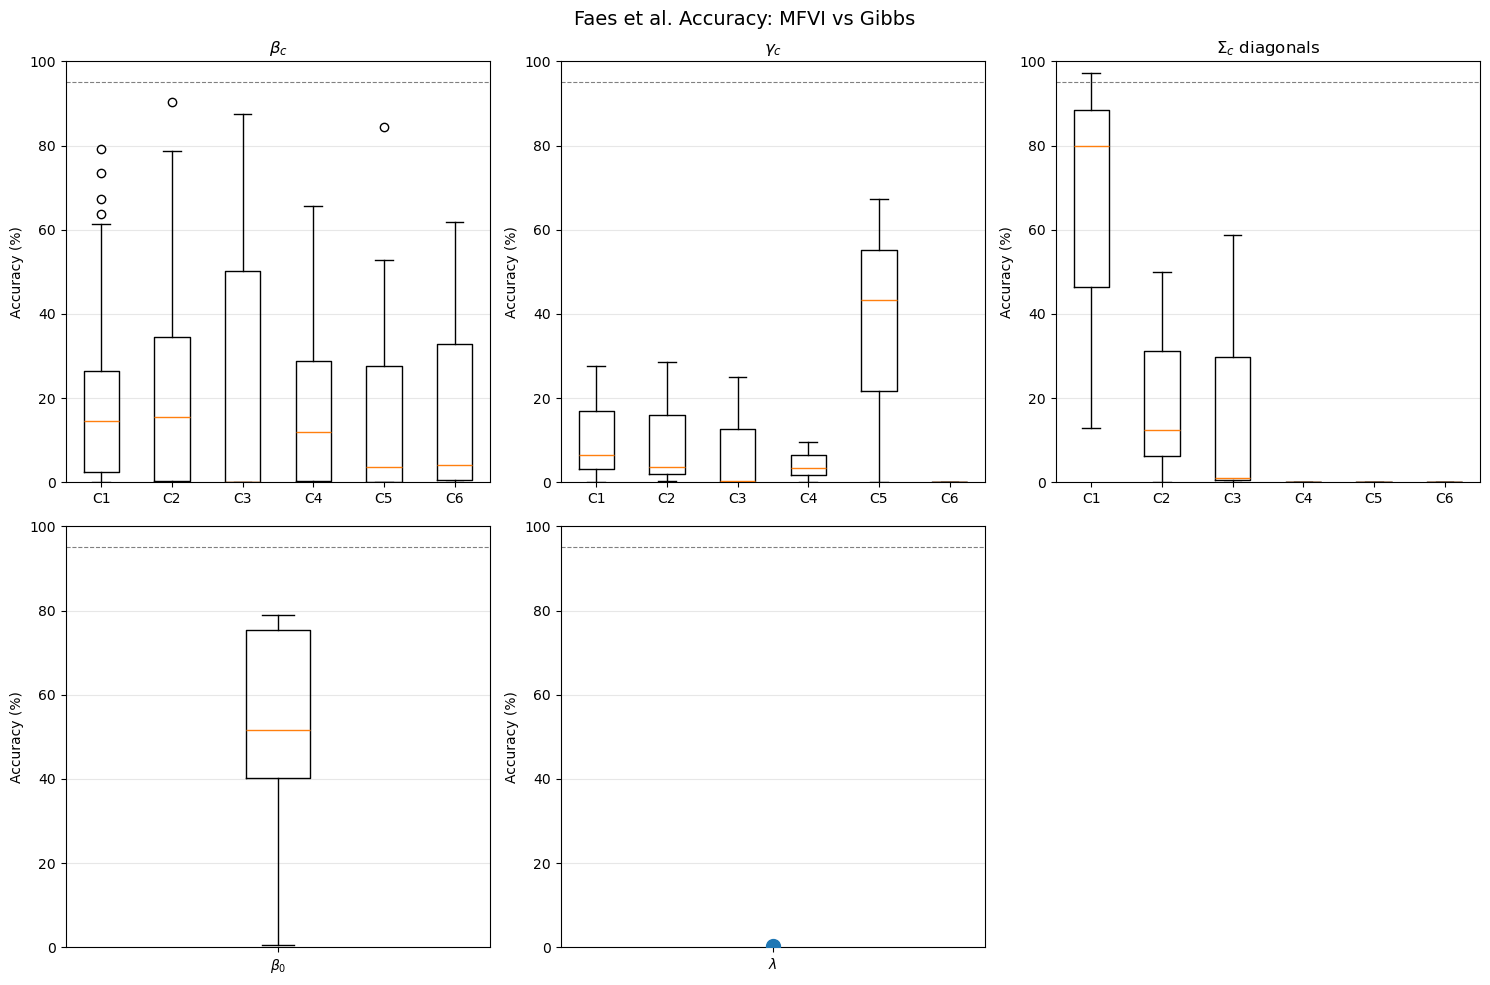

In [ ]:
"""Boxplots of Accuracy"""

country_labels = [f'C{c+1}' for c in range(C)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# beta_c: one box per country
axes[0, 0].boxplot([results_faes['beta_c'][c] for c in range(C)], labels=country_labels)
axes[0, 0].set_title(r'$\beta_c$')
axes[0, 0].set_ylabel('Accuracy (%)')

# gamma_c: one box per country
axes[0, 1].boxplot([results_faes['gamma_c'][c] for c in range(C)], labels=country_labels)
axes[0, 1].set_title(r'$\gamma_c$')
axes[0, 1].set_ylabel('Accuracy (%)')

# Sigma_c diagonals: one box per country
axes[0, 2].boxplot([results_faes['Sigma_c'][c] for c in range(C)], labels=country_labels)
axes[0, 2].set_title(r'$\Sigma_c$ diagonals')
axes[0, 2].set_ylabel('Accuracy (%)')

# beta_0: single box over all N*K coefficients
axes[1, 0].boxplot([results_faes['beta_0']], labels=[r'$\beta_0$'])
axes[1, 0].set_ylabel('Accuracy (%)')

# lambda: single value, shown as a point
axes[1, 1].scatter([1], [results_faes['lam']], s=100, zorder=5)
axes[1, 1].set_xlim(0.5, 1.5)
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels([r'$\lambda$'])
axes[1, 1].set_ylabel('Accuracy (%)')

axes[1, 2].set_visible(False)

for ax in axes.flat:
    if ax.get_visible():
        ax.set_ylim(0, 100)
        ax.axhline(y=95, color='grey', linestyle='--', linewidth=0.8)
        ax.grid(axis='y', alpha=0.3)

fig.suptitle('Faes et al. Accuracy: MFVI vs Gibbs', fontsize=14)
plt.tight_layout()
plt.show()

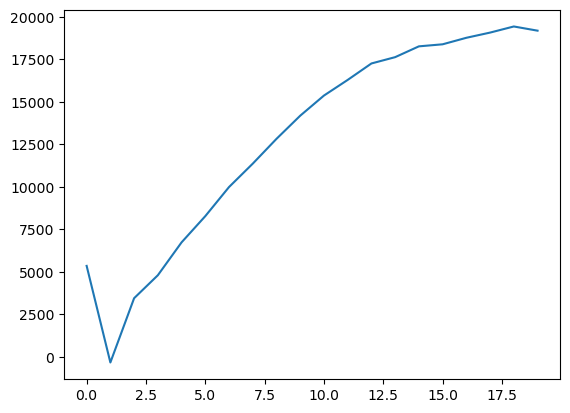

In [41]:
plt.plot(ELBO_ssvi)